## This notebook is used to reproduce the results in 4.3


============================== PROCESSING: SEMI-LOC_sw_aes ==============================
[Time] Analysis: 1.65s | Evaluation: 0.11s
[Eval] Hit Rate: 100.00% (50/50) | Pred: 50
[Auto] window=15000 | hop=11250 | thr=1.877 | seeds=25


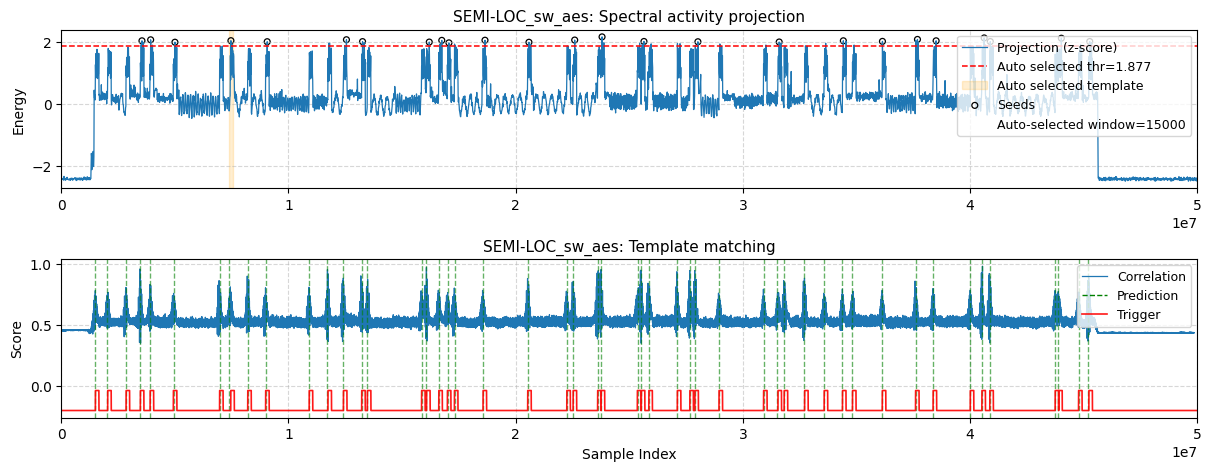


============================== PROCESSING: SEMI-LOC_hw_aes ==============================
[Time] Analysis: 1.86s | Evaluation: 0.10s
[Eval] Hit Rate: 100.00% (50/50) | Pred: 50
[Auto] window=1000 | hop=750 | thr=4.232 | seeds=25


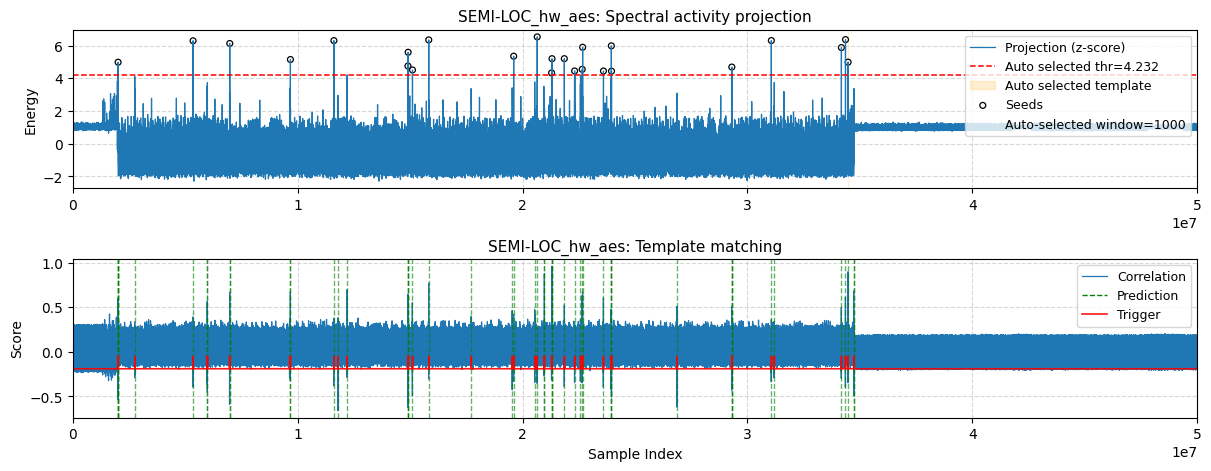


============================== PROCESSING: rd_aes_single ==============================
[Time] Analysis: 0.02s | Evaluation: 0.00s
[Eval] Hit Rate: 100.00% (10/10) | Pred: 10
[Auto] window=1000 | hop=750 | thr=2.267 | seeds=5


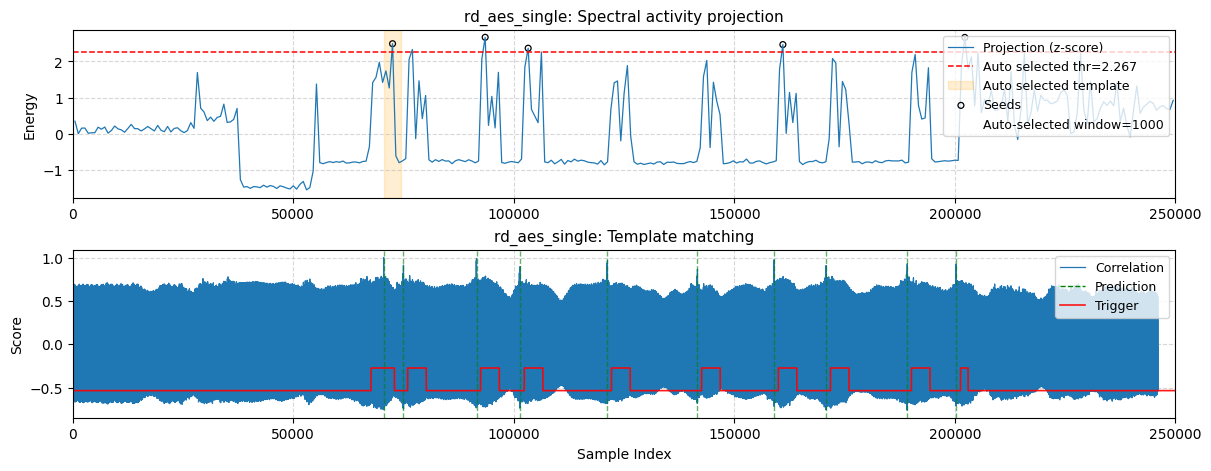


============================== PROCESSING: rd_aes_50 ==============================
[Time] Analysis: 2.21s | Evaluation: 0.16s
[Eval] Hit Rate: 100.00% (50/50) | Pred: 50
[Auto] window=3000 | hop=2250 | thr=5.494 | seeds=25


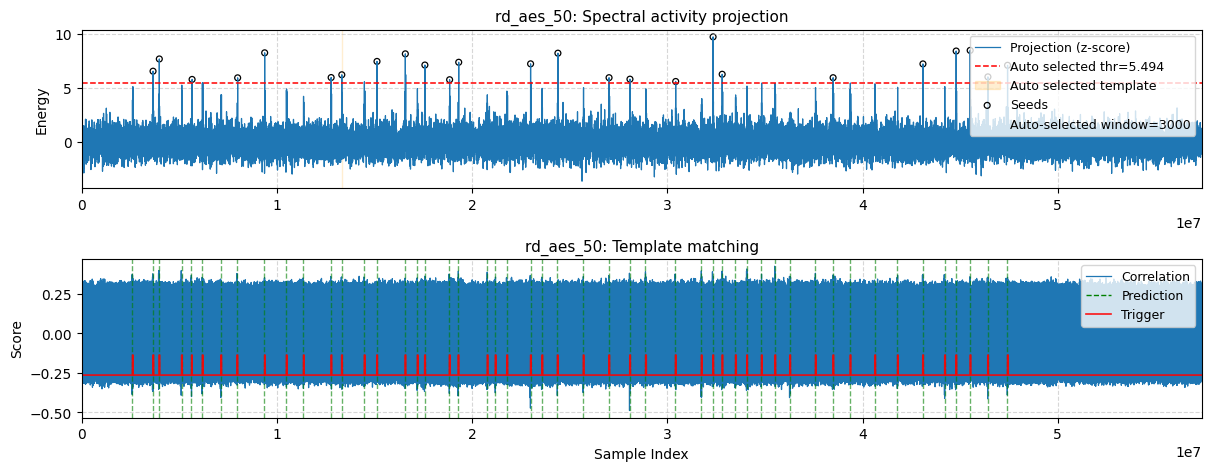


============================== PROCESSING: chameleon_base ==============================
[Time] Analysis: 1.87s | Evaluation: 0.04s
[Eval] Hit Rate: 92.31% (84/91) | Pred: 84
[Auto] window=14000 | hop=10500 | thr=1.675 | seeds=46


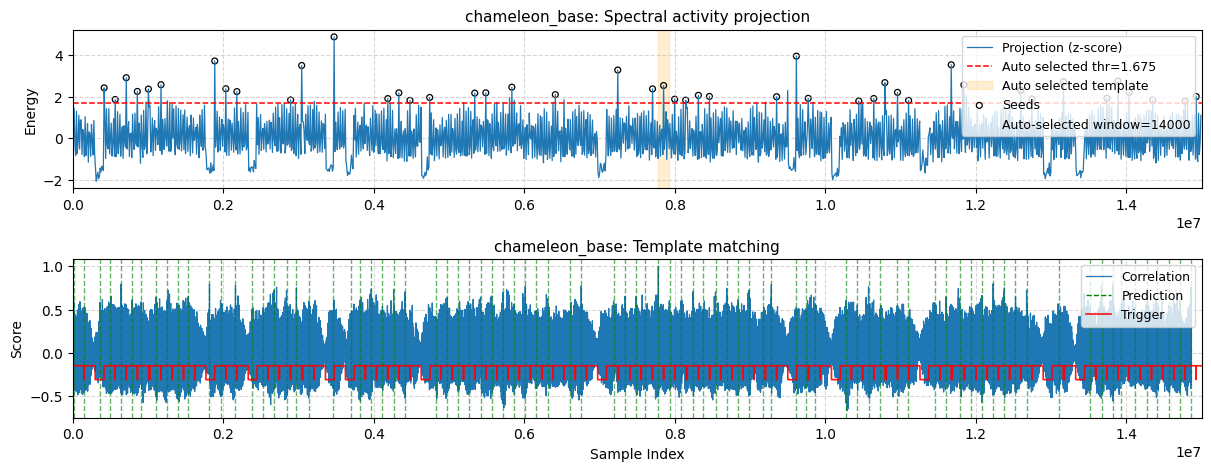


============================== PROCESSING: chameleon_mrp ==============================
[Time] Analysis: 0.59s | Evaluation: 0.03s
[Eval] Hit Rate: 98.44% (63/64) | Pred: 63
[Auto] window=14000 | hop=10500 | thr=1.419 | seeds=32


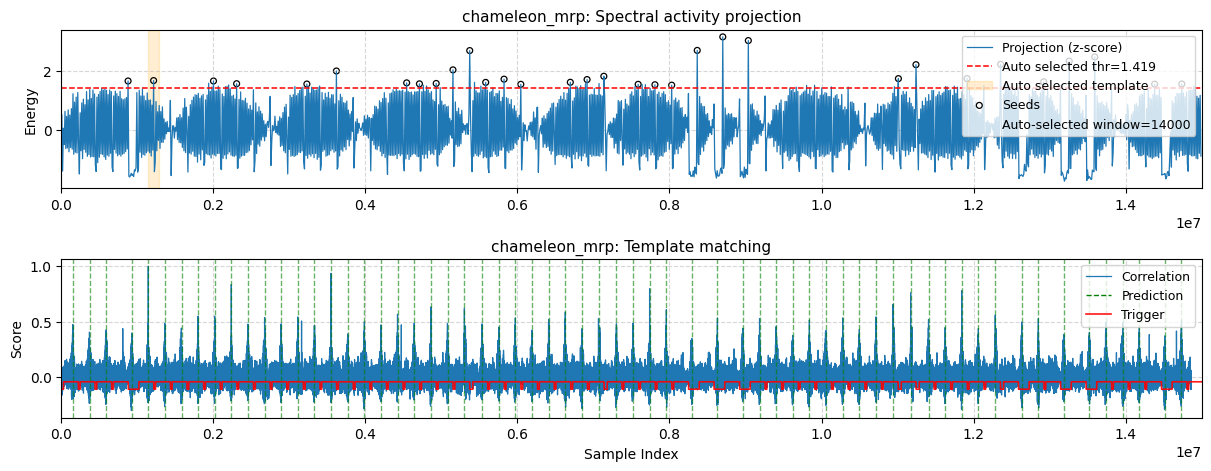


============================== PROCESSING: chameleon_chf ==============================
[Time] Analysis: 1.67s | Evaluation: 0.03s
[Eval] Hit Rate: 51.61% (16/31) | Pred: 16
[Auto] window=14000 | hop=10500 | thr=2.111 | seeds=16


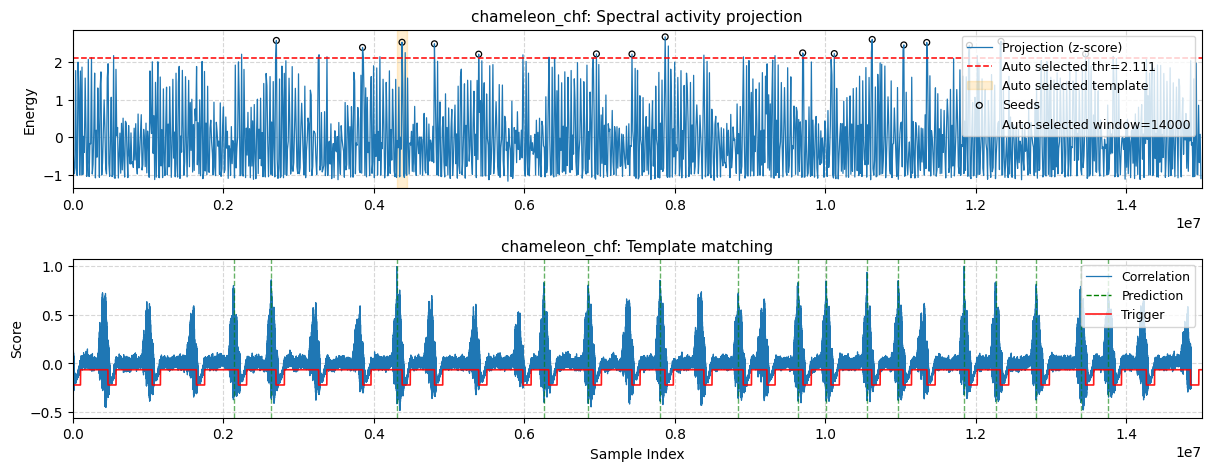


============================== PROCESSING: chameleon_rd ==============================
[Time] Analysis: 1.66s | Evaluation: 0.03s
[Eval] Hit Rate: 31.67% (19/60) | Pred: 21
[Auto] window=14000 | hop=10500 | thr=1.864 | seeds=30


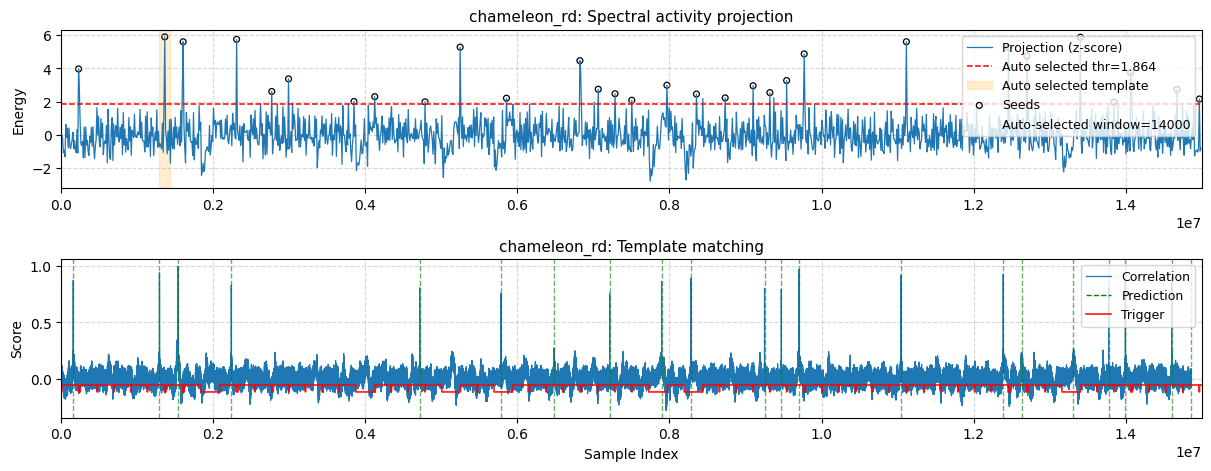


============================== PROCESSING: chameleon_dfs ==============================
[Time] Analysis: 1.62s | Evaluation: 0.03s
[Eval] Hit Rate: 7.84% (8/102) | Pred: 8
[Auto] window=14000 | hop=10500 | thr=1.456 | seeds=51


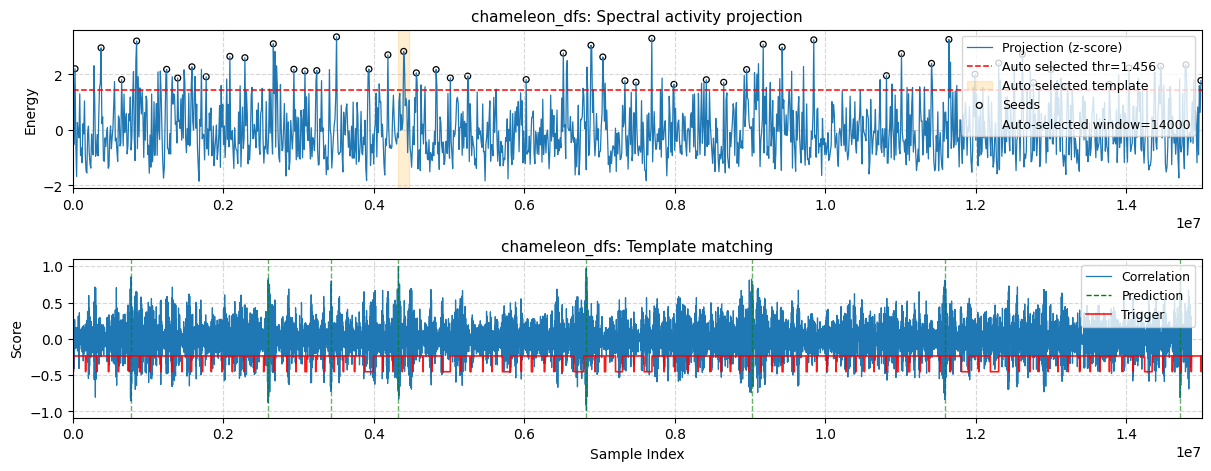

In [1]:
import time
import os
import sys
sys.path.append(os.path.abspath(''))
import numpy as np
import random

from src.self_temp_auto import (
    DatasetConfig,
    run_analysis,
    evaluate_analysis,
    visualize_paper_overview
)

# for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ============================================================
# Configs
# ============================================================
fs = 100.0e6  # only used to draw Spectrogram
noise_std = 0.0 # used to add noise

configs = [
    DatasetConfig(
        name="SEMI-LOC_sw_aes",
        signal_path="./dataset/semi-loc/stm32f4/STM32F4_TinyAes_125MSPS_50M_NoLowPass_new.npy",
        trigger_path="./dataset/semi-loc/stm32f4/STM32F4_TinyAes_125MSPS_50M_NoLowPass_new_trig.npy",
        target_length=150000,   # L
        target_k=50,            # K

        # following parameters are never used to analysis
        fs=fs,
        trigger_threshold_raw=190,
        noise_std=noise_std
    ),
    DatasetConfig(
        name="SEMI-LOC_hw_aes",
        signal_path="./dataset/semi-loc/stm32f4/STM32F4_HWAES_500MSPS_50M_NoLowPass.npy",
        trigger_path="./dataset/semi-loc/stm32f4/STM32F4_HWAES_500MSPS_50M_NoLowPass_trig.npy",
        target_length=5000,     # L
        target_k=50,            # K

        fs=fs,
        trigger_threshold_raw=190,
        noise_std=noise_std
    ),
    DatasetConfig(
        name="rd_aes_single",
        signal_path="./dataset/trace-copilot/aes_rand/aes_rand.npy",
        trigger_path="./dataset/trace-copilot/aes_rand/aes_rand_trig.npy",
        target_length=4000,
        target_k=10,

        fs=fs,
        trigger_threshold_raw=10000,
        noise_std=0
    ),
    DatasetConfig(
        name="rd_aes_50",
        signal_path="./dataset/em/aes_rd/traces.npy",
        trigger_path="./dataset/em/aes_rd/triggers.npy",
        target_length=30000,
        target_k=50,

        fs = fs,
        trigger_threshold_raw=1.5,
        noise_std=noise_std,
    ),
    DatasetConfig(
        name="chameleon_base",
        signal_path="./dataset/chameleon_lowpass/chameleon_base_chunk_1_trace.npy",
        trigger_path="./dataset/chameleon_lowpass/chameleon_base_chunk_1_trigger.npy",
        target_length=140000,   # L
        target_k=91,            # K

        fs=fs,
        trigger_threshold_raw=3,
        noise_std=noise_std
    ),
    DatasetConfig(
        name="chameleon_mrp",
        signal_path="./dataset/chameleon_lowpass/chameleon_mrp_chunk_1_trace.npy",
        trigger_path="./dataset/chameleon_lowpass/chameleon_mrp_chunk_1_trigger.npy",
        target_length=140000,
        target_k=63,

        fs=fs,
        trigger_threshold_raw=3,
        noise_std=noise_std,
    ),
    DatasetConfig(
        name="chameleon_chf",
        signal_path="./dataset/chameleon_lowpass/chameleon_chf_chunk_1_trace.npy",
        trigger_path="./dataset/chameleon_lowpass/chameleon_chf_chunk_1_trigger.npy",
        target_length=140000,   # L
        target_k=31,            # K

        fs=fs,
        trigger_threshold_raw=3,
        noise_std=noise_std
    ),
    DatasetConfig(
        name="chameleon_rd",
        signal_path="./dataset/chameleon_lowpass/chameleon_rd_chunk_1_trace.npy",
        trigger_path="./dataset/chameleon_lowpass/chameleon_rd_chunk_1_trigger.npy",
        target_length=140000,   # L
        target_k=60,            # K

        fs=fs,
        trigger_threshold_raw=3,
        noise_std=noise_std
    ),
    DatasetConfig(
        name="chameleon_dfs",
        signal_path="./dataset/chameleon_lowpass/chameleon_dfs_chunk_1_trace.npy",
        trigger_path="./dataset/chameleon_lowpass/chameleon_dfs_chunk_1_trigger.npy",
        target_length=140000,   # L
        target_k=102,            # K

        fs=fs,
        trigger_threshold_raw=3,
        noise_std=noise_std
    ),
]


if __name__ == "__main__":
    for cfg in configs:
        print("\n" + "=" * 30 + f" PROCESSING: {cfg.name} " + "=" * 30)

        # 1) Analyze
        t0 = time.time()
        ar = run_analysis(cfg)
        t_analysis = time.time() - t0

        # 2) Evaluate
        t0 = time.time()
        rep = evaluate_analysis(ar)
        t_eval = time.time() - t0

        print(f"[Time] Analysis: {t_analysis:.2f}s | Evaluation: {t_eval:.2f}s")
        if rep.get("hit_rate") is not None:
            print(f"[Eval] Hit Rate: {rep['hit_rate']:.2%} ({rep['hits']}/{rep['gt_count']}) | Pred: {rep['pred_count']}")
        else:
            print(f"[Eval] N/A ({rep.get('reason')})")

        # 3) Plot Figure A
        if ar.pred_peaks is not None:
            print(f"[Auto] window={ar.sel_window} | hop={ar.sel_hop} | thr={ar.sel_thr:.3f} | seeds={ar.seed_peaks_samples.size if ar.seed_peaks_samples is not None else 0}")
            
            # trigger height for hw is too small, so we enlarge it when plot
            trig_h = 0.28 if "hw" in cfg.name else 0.20
            
            visualize_paper_overview(
                ar,
                view_range=None,
                max_points=250_000,
                figsize=(12.0, 4.6),
                save_path=None,
                trigger_height_ratio=trig_h,
                trigger_baseline_ratio=0.08
            )
        else:
            print("[Warn] Analysis failed, skipping plot.")
            if ar.debug:
                print("[Debug]", ar.debug)

In [2]:
import dataclasses
import pandas as pd
import numpy as np
import hashlib

noise_std_list = [0.5, 1.0, 2.0, 3.0, 5.0]
REPEAT = 10
BASE_SEED = 42

def derive_seed(base_seed: int, dataset_name: str, noise_std: float, rep: int) -> int:
    msg = f"{base_seed}|{dataset_name}|{noise_std:.10g}|{rep}".encode("utf-8")
    digest = hashlib.blake2b(msg, digest_size=8).digest()
    return int.from_bytes(digest, "little") & 0xFFFFFFFF

results = []

print(f"{'='*20} Noise Repeat Experiment {'='*20}")
print(f"REPEAT={REPEAT}, BASE_SEED={BASE_SEED}")
print(f"noise_std_list={noise_std_list}")

for std in noise_std_list:
    print(f"\n--- Noise Std: {std} ---")

    for base_cfg in configs:
        hit_rates = []

        for rep in range(REPEAT):
            run_seed = derive_seed(BASE_SEED, base_cfg.name, float(std), rep)
            cfg = dataclasses.replace(base_cfg, noise_std=float(std))

            try:
                ar = run_analysis(cfg, rng_seed=run_seed)
                ev = evaluate_analysis(ar)
                hr = ev.get("hit_rate", None)

                if hr is None or (isinstance(hr, float) and (np.isnan(hr) or np.isinf(hr))):
                    hr = 0.0
                    note = " (hit_rate=None->0)"
                else:
                    hr = float(hr)
                    note = ""

                hit_rates.append(hr)
                print(f"Dataset: {base_cfg.name:<20} | Rep: {rep:02d} | seed={run_seed:<10d} | hit_rate={hr:.2%}{note}")

            except Exception as e:
                hit_rates.append(0.0)
                print(f"Dataset: {base_cfg.name:<20} | Rep: {rep:02d} | seed={run_seed:<10d} | Error: {e} (-> hit_rate=0)")

        mean_hit = float(np.mean(hit_rates)) if hit_rates else 0.0
        print(f"Dataset: {base_cfg.name:<20} | Mean Hit Rate over {REPEAT}: {mean_hit:.2%}")

        results.append({
            "Dataset": base_cfg.name,
            "Noise_Std": float(std),
            "Mean_Hit_Rate": mean_hit,
            "Repeat": int(REPEAT),
        })

print(f"\n{'='*20} Result Pivot {'='*20}")
df = pd.DataFrame(results)
pivot = df.pivot(index="Dataset", columns="Noise_Std", values="Mean_Hit_Rate")
print(pivot.applymap(lambda x: f"{x:.2%}"))


==================== Noise Repeat Experiment ====================
REPEAT=10, BASE_SEED=42
noise_std_list=[0.5, 1.0, 2.0, 3.0, 5.0]

--- Noise Std: 0.5 ---
Dataset: SEMI-LOC_sw_aes      | Rep: 00 | seed=4161245202 | hit_rate=100.00%
Dataset: SEMI-LOC_sw_aes      | Rep: 01 | seed=867975191  | hit_rate=100.00%
Dataset: SEMI-LOC_sw_aes      | Rep: 02 | seed=2444040585 | hit_rate=100.00%
Dataset: SEMI-LOC_sw_aes      | Rep: 03 | seed=3910556940 | hit_rate=100.00%
Dataset: SEMI-LOC_sw_aes      | Rep: 04 | seed=2525175790 | hit_rate=100.00%
Dataset: SEMI-LOC_sw_aes      | Rep: 05 | seed=2672154538 | hit_rate=100.00%
Dataset: SEMI-LOC_sw_aes      | Rep: 06 | seed=2989392737 | hit_rate=100.00%
Dataset: SEMI-LOC_sw_aes      | Rep: 07 | seed=3877406125 | hit_rate=100.00%
Dataset: SEMI-LOC_sw_aes      | Rep: 08 | seed=2977242083 | hit_rate=100.00%
Dataset: SEMI-LOC_sw_aes      | Rep: 09 | seed=362198811  | hit_rate=100.00%
Dataset: SEMI-LOC_sw_aes      | Mean Hit Rate over 10: 100.00%

--- Noise S

/var/folders/f8/jsfljvz136v32ls7xnpds8lh0000gn/T/ipykernel_86761/3560564092.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(pivot.applymap(lambda x: f"{x:.2%}"))


In [3]:
import dataclasses
import pandas as pd

length_ratio_list = [0.1, 0.5, 1.5, 2, 5]
seed_value = 42
results_length = []
SEED = 42
np.random.seed(SEED)
random.seed(SEED)


print(f"{'='*20} Length Test) {'='*20}")

for ratio in length_ratio_list:
    
    print(f"\n--- Testing Target Length Ratio: {ratio} ---")
    
    for base_cfg in configs:
        new_L = int(base_cfg.target_length * ratio)
        
        current_cfg = dataclasses.replace(base_cfg, target_length=new_L)

        try:
            # Run Analysis
            ar = run_analysis(current_cfg)
            # Evaluate
            eval_res = evaluate_analysis(ar)
            
            hit_rate = eval_res.get("hit_rate", 0.0)
            print(f"Dataset: {base_cfg.name:<20} | L_new: {new_L:<8} | Hit Rate: {hit_rate:.2%}")
            
            results_length.append({
                "Dataset": base_cfg.name,
                "Ratio": ratio,
                "Hit_Rate": hit_rate
            })
            
        except Exception as e:
            print(f"Dataset: {base_cfg.name:<20} | Error: {e}")
            results_length.append({
                "Dataset": base_cfg.name,
                "Ratio": ratio,
                "Hit_Rate": -1.0
            })

print(f"\n{'='*20} Result {'='*20}")
df_length = pd.DataFrame(results_length)
pivot_length = df_length.pivot(index="Dataset", columns="Ratio", values="Hit_Rate")
print(pivot_length.applymap(lambda x: f"{x:.2%}" if x >= 0 else "Error"))

==================== Length Test) ====================

--- Testing Target Length Ratio: 0.1 ---
Dataset: SEMI-LOC_sw_aes      | L_new: 15000    | Hit Rate: 56.00%
Dataset: SEMI-LOC_hw_aes      | L_new: 500      | Hit Rate: 100.00%
Dataset: rd_aes_single        | L_new: 400      | Hit Rate: 90.00%
Dataset: rd_aes_50            | L_new: 3000     | Hit Rate: 96.00%
Dataset: chameleon_base       | L_new: 14000    | Hit Rate: 59.34%
Dataset: chameleon_mrp        | L_new: 14000    | Hit Rate: 53.12%
Dataset: chameleon_chf        | L_new: 14000    | Hit Rate: 67.74%
Dataset: chameleon_rd         | L_new: 14000    | Hit Rate: 75.00%
Dataset: chameleon_dfs        | L_new: 14000    | Hit Rate: 10.78%

--- Testing Target Length Ratio: 0.5 ---
Dataset: SEMI-LOC_sw_aes      | L_new: 75000    | Hit Rate: 98.00%
Dataset: SEMI-LOC_hw_aes      | L_new: 2500     | Hit Rate: 100.00%
Dataset: rd_aes_single        | L_new: 2000     | Hit Rate: 100.00%
Dataset: rd_aes_50            | L_new: 15000    | Hit 

/var/folders/f8/jsfljvz136v32ls7xnpds8lh0000gn/T/ipykernel_86799/2848794037.py:49: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(pivot_length.applymap(lambda x: f"{x:.2%}" if x >= 0 else "Error"))
